In [1]:
import numpy as np
import pandas as pd
from numba import jit

import matplotlib
matplotlib.rcParams['image.cmap'] = 'jet'
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.metrics import roc_auc_score

$$
X^\top X + \lambda I = (X^\top X) I + \lambda I
$$

In [2]:
def compute_xtx(xmat, uidx, iidx, lparam, nuser, nitem):
    xtx_mat = np.zeros((nitem, nitem))
    xdense = np.zeros((nuser, nitem))
    for idx in range(xmat.size):
        xdense[uidx[idx], iidx[idx]] = xmat[[idx]]
    return np.dot(np.transpose(xdense), xdense) + lparam * np.eye(nitem)
    

In [3]:
@jit(nopython=True, fastmath=True)
def compute_sparse_matrix_dense_matrix_product(smat, uidx, iidx, nuser, bmat):
    nitem, _ = np.shape(bmat)
    score = np.zeros((nuser, nitem))
    for idx in range(smat.size):
        score[uidx[idx], :] += smat[idx] * bmat[iidx[idx],  :]
    return score

inside the main function
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596
(100000, 4)
0
942
0
1681
[3 3 1 2 1 4 2 5 3 3]
nuser = 943
nitem = 1682
1
5


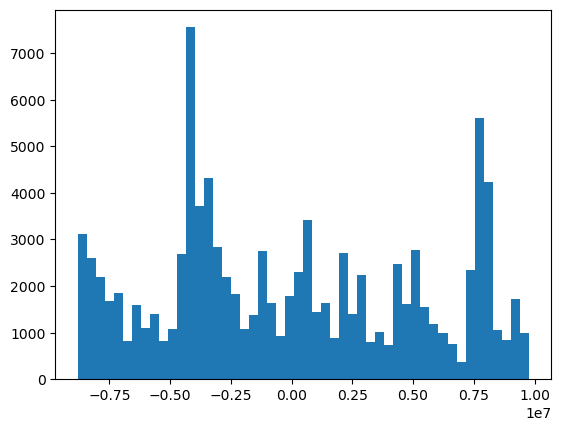

npos = 55375
nneg = 44625
bmat.shape = (1682, 1682)


/var/folders/5j/z1s2qnbx1p135jktbyvf7ddm0000gq/T/ipykernel_11954/663509449.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  xdense[uidx[idx], iidx[idx]] = xmat[[idx]]


(1682, 1682)
bmat.shape = (1682, 1682)


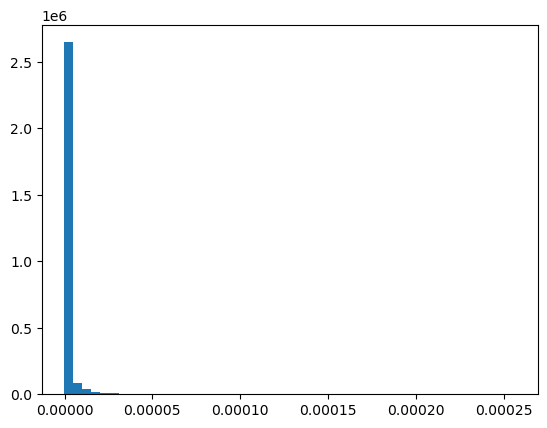

-1.0580100112318989e-08
2.382711457031318e-05
roc_auc_train = 0.7014031059557252
roc_auc_ttest = 0.6539345278496


0

In [11]:
def get_positives_and_negatives(idata, rtarget):
    nedge = idata.shape[0]
    emat = np.zeros(nedge)
    uidx = np.zeros((nedge), dtype=np.int64)
    iidx = np.zeros((nedge), dtype=np.int64)
    nneg = 0
    npos = 0

    for idx in range(idata.shape[0]):
        uidx[idx] = idata[idx, 0]
        iidx[idx] = idata[idx, 1]
        if idata[idx, 2] >= rtarget:
            npos += 1
            emat[idx] = 1.0
        else:
            nneg += 1
            emat[idx] = 0.0
    print('npos = ' + str(npos))
    print('nneg = ' + str(nneg))
    return (emat, uidx, iidx)
    
def train_test_split(emat, uidx, iidx, timestemp_data, frac_train=0.7):
    t_threshold = np.quantile(timestemp_data, frac_train)
    nedge = emat.size
    emat_train = []
    uidx_train = []
    iidx_train = []
    emat_ttest = []
    uidx_ttest = []
    iidx_ttest = []
    for iedge in range(nedge):
        if timestemp_data[iedge] <= t_threshold:
            emat_train.append(emat[iedge])
            uidx_train.append(uidx[iedge])
            iidx_train.append(iidx[iedge])
        else:
            emat_ttest.append(emat[iedge])
            uidx_ttest.append(uidx[iedge])
            iidx_ttest.append(iidx[iedge])
    emat_train = np.asarray(emat_train, dtype=np.float64)
    uidx_train = np.asarray(uidx_train, dtype=np.int64)
    iidx_train = np.asarray(iidx_train, dtype=np.int64)

    emat_ttest = np.asarray(emat_ttest, dtype=np.float64)
    uidx_ttest = np.asarray(uidx_ttest, dtype=np.int64)
    iidx_ttest = np.asarray(iidx_ttest, dtype=np.int64)
    
    return (emat_train, uidx_train, iidx_train,
            emat_ttest, uidx_ttest, iidx_ttest)


    
def recom_ease():
    print('inside the main function')
    ratings = pd.read_csv('./ml-100k/u.data', sep='\t', names=['user_id', 'movie_id', 'rating', 'timestamp'])
    print(ratings.head())
    idata = ratings.values
    print(idata.shape)
    idata[:, 0] -= 1
    idata[:, 1] -= 1
    nuser = np.max(idata[:, 0]) + 1
    nitem = np.max(idata[:, 1]) + 1
    print(np.min(idata[:, 0]))
    print(np.max(idata[:, 0]))
    print(np.min(idata[:, 1]))
    print(np.max(idata[:, 1]))
    print(idata[:10, 2])
    print('nuser = ' + str(nuser))
    print('nitem = ' + str(nitem))
    print(np.min(idata[:, 2]))
    print(np.max(idata[:, 2]))

    idata[:, 3] = idata[:, 3] - np.mean(idata[:, 3])
    plt.figure()
    plt.hist(idata[:, 3], bins=50)
    plt.show()
    rtarget = 4.0
    emat, uidx, iidx = get_positives_and_negatives(idata, rtarget)
    emat_train, uidx_train, iidx_train, emat_ttest, uidx_ttest, iidx_ttest = train_test_split(emat, uidx, iidx, idata[:, 3], frac_train=0.7)
    bmat = np.zeros((nitem, nitem))
    print('bmat.shape = ' + str(bmat.shape))

    lparam = 1.0e+6
    amat = compute_xtx(emat_train, uidx_train, iidx_train, lparam, nuser, nitem)
    hmat = np.linalg.inv(amat)
    print(hmat.shape)
    
    bmat = - hmat
    for idx in range(nitem):
        bmat[idx, idx] = 0.0
        bmat[:, idx] = bmat[:, idx] / hmat[idx, idx]
    print('bmat.shape = ' + str(bmat.shape))
    plt.figure()
    plt.hist(bmat.flatten(), bins=50)
    plt.show()
    print(np.quantile(bmat.flatten(), 0.01))
    print(np.quantile(bmat.flatten(), 0.99))

    threshold_l = np.quantile(bmat.flatten(), 0.01)
    threshold_h = np.quantile(bmat.flatten(), 0.99)


    score_train_dense = compute_sparse_matrix_dense_matrix_product(emat_train, uidx_train,
                                                                   iidx_train, nuser, bmat)
    score_ttest_dense = compute_sparse_matrix_dense_matrix_product(emat_ttest, uidx_ttest,
                                                                   iidx_ttest, nuser, bmat)
    score_train = 0.0 * emat_train
    for idx in range(score_train.size):
        score_train[idx] = score_train_dense[uidx_train[idx], iidx_train[idx]]
    score_ttest = 0.0 * emat_ttest
    for idx in range(score_ttest.size):
        score_ttest[idx] = score_ttest_dense[uidx_ttest[idx], iidx_ttest[idx]]
    label_train = emat_train
    label_ttest = emat_ttest
    
    roc_auc_train = roc_auc_score(label_train, score_train)
    roc_auc_ttest = roc_auc_score(label_ttest, score_ttest)
    
    # item_data = pd.read_csv('./ml-100k/u.item', sep='\t', header=None)
    # print(item_data)
    # for idx0 in range(nitem):
    #     for idx1 in range(nitem):
    #         pass
    #         if bmat[idx0, idx1] < threshold_l:
    #             print('l_sim idx0 = ' + str(idx0) + ' idx1 = ' + str(idx1))
    #         if bmat[idx0, idx1] > threshold_h:
    #             print('h_sim idx0 = ' + str(idx0) + ' idx1 = ' + str(idx1))
    print('roc_auc_train = ' + str(roc_auc_train))
    print('roc_auc_ttest = ' + str(roc_auc_ttest))
    return 0

recom_ease()